# Temperature Anomaly Detection

**Course:** Deep Learning  
**Dataset:** SIATA — 4 meteorological stations in Medellín, Valle de Aburrá  
**Date range:** 2025-01-01 → 2025-10-31 (10 months, 1,658,169 minutely records)  
**Task:** Binary anomaly detection on sliding temperature windows  

## Problem Description

The **SIATA** (Sistema de Alerta Temprana de Medellín y el Valle de Aburrá) network monitors urban meteorological conditions at 1-minute resolution across the Aburrá Valley. Sensor failures and transmission errors produce **temperature anomalies** — readings that fall outside the expected physical range or are inconsistent with correlated variables.

The `temperatura_dudosa` field provides ground-truth labels (~3.6% positive rate across stations with anomalies). We treat this as a **supervised binary classification** problem: given a 30-minute sliding window of temperature readings, predict whether the last timestep is anomalous.

---

## Experimental Design

### Pipeline Stages

1. **EDA** — visualize per-station time series and anomaly distribution
2. **Preprocessing** — normalize features with `StandardScaler`; build 30-minute sliding windows with stride=5.
3. **Temporal split** — each station split chronologically: 35% train / 20% val / 45% test. Done *before* windowing to prevent leakage. The non-standard ratio is required because all labeled anomalies are concentrated in Jan–Jun 2025; a standard 70/15/15 split leaves val and test entirely anomaly-free.
4. **Training** — `EarlyStopping(patience=5)` on validation loss; `restore_best_weights=True`.
5. **Threshold calibration** — F1-optimal threshold swept on validation set (range 0.05–0.95); not fixed at 0.5.
6. **Evaluation** — Precision, Recall, F1, AUC-PR on held-out test set.

### Experiments

| Exp | Model | Training strategy | Purpose |
|---|---|---|---|
| E1 | MLP Baseline | Supervised, all stations | Establish baseline |
| E2 | 1D-CNN + Residual Block | Supervised, all stations | Architecture complexity |
| E3a | CNN — frozen backbone | Pre-train on 68+201, freeze, train head on 20% of station 203 | Transfer learning |
| E3b | CNN — fine-tuned | Same backbone, unfreeze all layers on 20% of station 203 | Full fine-tune |
| E3c | CNN — scratch | Same architecture, random init on 20% of station 203 | TL lower bound |

### Evaluation Metrics

**Accuracy is not used** — a model that always predicts "normal" achieves 96.4% accuracy but detects zero anomalies.

| Metric | Description |
|---|---|
| **Precision** | Of all predicted anomalies, what fraction are real |
| **Recall** | Of all real anomalies, what fraction were detected |
| **F1** | Harmonic mean of precision and recall — primary ranking metric |
| **AUC-PR** | Area under precision-recall curve — threshold-independent, preferred for imbalanced data |

**Class imbalance** is handled with weighted binary crossentropy: the anomaly class receives a loss multiplier of `n_negative / n_positive ≈ 27×`.

## Setup

In [2]:
!pip install -q tensorflow pandas scikit-learn matplotlib seaborn gdown

In [3]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Clone the repo to make siata_anomaly available
    REPO_URL = 'https://github.com/daissyherrera/TrabajoFinal_DeepL.git'
    BRANCH = 'main'
    !rm -rf /content/repo && git clone -b {BRANCH} {REPO_URL} /content/repo
    REPO_PATH = '/content/repo'

    # Download data from Google Drive (too large to include in the repo)
    !gdown '1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz' -O /content/temperatura_estaciones_2025.csv
    DATA_PATH = '/content/temperatura_estaciones_2025.csv'
else:
    REPO_PATH = os.path.abspath('.')
    DATA_PATH = os.path.join(REPO_PATH, 'data', 'temperatura_estaciones_2025.csv')

sys.path.insert(0, REPO_PATH)

# Reproducibility
import numpy as np
import tensorflow as tf
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from siata_anomaly import (
    load_csv, preprocess, make_windows, split_data, compute_class_weight,
    build_mlp, build_cnn_backbone, attach_head, weighted_binary_crossentropy,
    AnomalyDetector,
    precision_recall_f1, plot_confusion_matrix, plot_training_history, summary_table
)

WINDOW_SIZE = 30   # 30-minute sliding window
STEP        = 5    # stride=5 reduces dataset size 5x while preserving patterns
EPOCHS      = 20
BATCH_SIZE  = 256
print('TF version:', tf.__version__)

Cloning into '/content/repo'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 104 (delta 57), reused 52 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 958.42 KiB | 17.43 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Downloading...
From (original): https://drive.google.com/uc?id=1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz
From (redirected): https://drive.google.com/uc?id=1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz&confirm=t&uuid=9cd5f982-c74b-4249-a155-b43e0a991d5f
To: /content/temperatura_estaciones_2025.csv
100% 150M/150M [00:05<00:00, 26.8MB/s]
TF version: 2.19.0


## 1. Data Loading & Exploratory Analysis

In [4]:
df = load_csv(DATA_PATH)
print('Shape:', df.shape)
print('Date range:', df['fecha_hora'].min(), '→', df['fecha_hora'].max())
df.head(3)

Shape: (1658169, 14)
Date range: 2025-01-01 00:00:00 → 2025-10-31 23:59:00


,codigo,estacion_nombre,fecha_hora,h,t,pr,vv,vv_max,dv,dv_max,p,calidad,calidad_dudosa,temperatura_dudosa
0,68,Jardin Botanico,2025-01-01 00:00:00,87.8,19.3,852.0,1.6,2.8,18.0,1.0,0.0,153,True,True
1,68,Jardin Botanico,2025-01-01 00:01:00,87.6,19.3,852.0,1.8,2.5,16.0,21.0,0.0,153,True,True
2,68,Jardin Botanico,2025-01-01 00:02:00,87.5,19.3,851.9,2.0,3.5,27.0,40.0,0.0,153,True,True


### Dataset Description

**Source:** SIATA open data portal — `temperatura_estaciones_2025.csv`  
**Records:** 1,658,169 minutely observations across 4 stations, January–October 2025  
**Missing values:** none (original `-999` sentinel values were replaced with `NaN` and rows without temperature dropped during cleaning)

#### Columns

| Column | Type | Unit | Description |
|---|---|---|---|
| `codigo` | int | — | Station identifier (68, 201, 203, 478) |
| `estacion_nombre` | str | — | Station name |
| `fecha_hora` | datetime | — | Timestamp at 1-minute frequency |
| `h` | float | % | Relative humidity |
| `t` | float | °C | Ambient temperature — **the feature used in this study** |
| `pr` | float | hPa | Atmospheric pressure |
| `vv` | float | m/s | Average wind speed |
| `vv_max` | float | m/s | Maximum wind gust |
| `dv` | float | ° | Average wind direction (0–360°) |
| `dv_max` | float | ° | Wind direction at maximum gust |
| `p` | float | mm | Cumulative precipitation during the minute |
| `calidad` | int | — | SIATA quality index: `1`/`2` = reliable; `153` = doubtful temperature |
| `calidad_dudosa` | bool | — | `True` if any variable has doubtful quality |
| `temperatura_dudosa` | bool | — | `True` if temperature is anomalous — **anomaly label** |

#### Per-station statistics

| Code | Station | Records | Anomalies | Anomaly rate |
|---|---|---|---|---|
| 68 | Jardin Botanico | 423,630 | 7,676 | 1.81% |
| 201 | Torre SIATA | 402,325 | 9,397 | 2.34% |
| 203 | UNAL | 435,801 | 6,728 | 1.54% |
| 478 | Fiscalia General | 396,413 | 0 | **0.00%** |

> **Station 478 (Fiscalia General)** recorded zero labeled anomalies across all 10 months. It is included in E1/E2 to enrich the training distribution of normal readings, but is excluded from E3 (transfer learning) because no labeled anomalies are available for supervised evaluation or fine-tuning of the target domain.

                  Total records  Anomalies Anomaly rate
estacion_nombre                                        
Fiscalia General         396413          0        0.00%
Jardin Botanico          423630       7676        1.81%
Torre SIATA              402325       9397        2.34%
UNAN                     435801       6728        1.54%


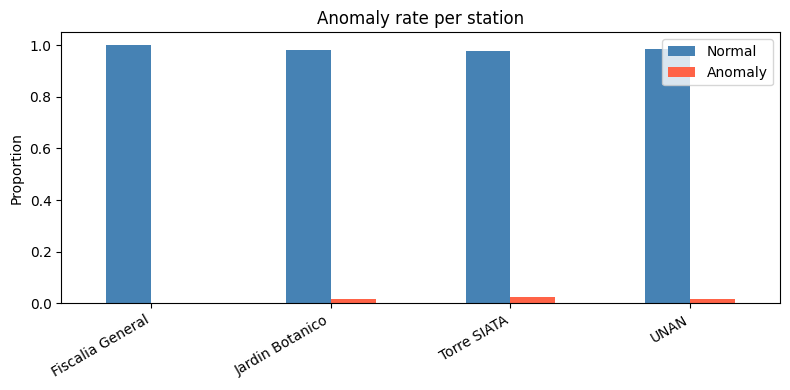

In [5]:
# Anomaly distribution per station
stats = df.groupby('estacion_nombre')['temperatura_dudosa'].agg(['count', 'sum', 'mean'])
stats.columns = ['Total records', 'Anomalies', 'Anomaly rate']
stats['Anomaly rate'] = stats['Anomaly rate'].map('{:.2%}'.format)
print(stats)

fig, ax = plt.subplots(figsize=(8, 4))
groups = df.groupby('estacion_nombre')['temperatura_dudosa'].value_counts(normalize=True).unstack()
groups.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Anomaly rate per station')
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.legend(['Normal', 'Anomaly'])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

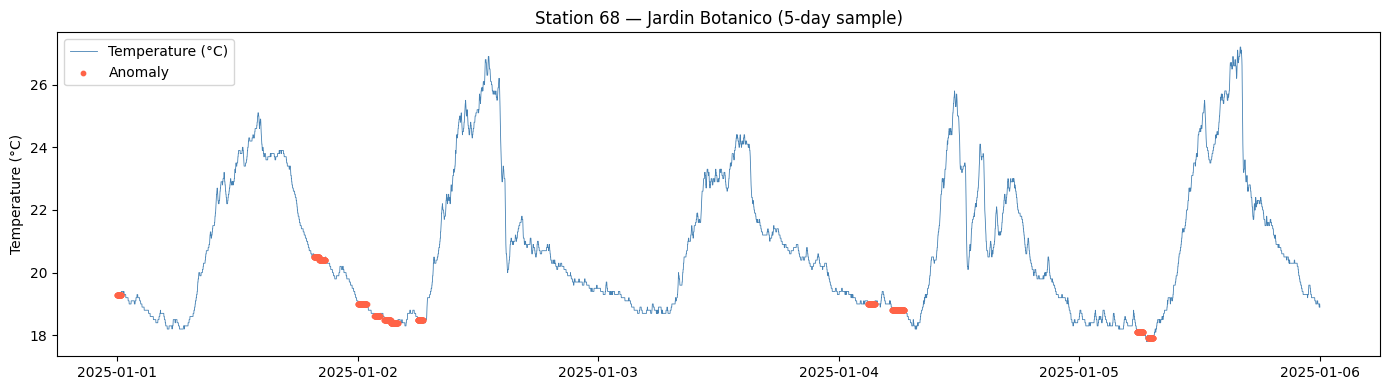

In [6]:
# Temperature time series — sample 5 days from station 68
sample = df[df['codigo'] == 68].iloc[:7200]   # 5 days × 1440 min/day
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample['fecha_hora'], sample['t'], lw=0.6, color='steelblue', label='Temperature (°C)')
anomalies = sample[sample['temperatura_dudosa']]
ax.scatter(anomalies['fecha_hora'], anomalies['t'], color='tomato', s=10, zorder=5, label='Anomaly')
ax.set_title('Station 68 — Jardin Botanico (5-day sample)')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Preprocessing

Each sample is a **30-minute sliding window** of 1 feature: temperature (`t`). The label is `temperatura_dudosa` at the last timestep of each window.

**Class imbalance** (~3.6% anomalies) is handled with **weighted binary crossentropy** — the anomaly class receives a loss multiplier of `n_negative / n_positive ≈ 27×`.

### Why temporal split instead of random split

For time-series data, a random shuffle causes **data leakage** through overlapping windows. With `window_size=30` and `step=5`, consecutive windows share 25 timesteps. If window `i` goes to train and window `i+5` goes to test, the model effectively "sees" test data during training — inflating evaluation metrics artificially.

The correct approach is a **chronological split**: each station's records are divided in time order, windows are created **after** the split, and the scaler is fitted **only on training data** then applied to val/test.

### Why 35% / 20% / 45% instead of the standard 70/15/15

Exploratory analysis revealed that all labeled anomalies in this dataset are **temporally concentrated in January–June 2025** — after June 29 no station records any labeled fault. With a 70/15/15 split, both val and test fall entirely in the anomaly-free period (Jul–Oct), making supervised evaluation impossible (F1=0 for every model regardless of quality).

The 35/20/45 split is the smallest train fraction for which **all three partitions contain positive examples** across all active stations:

| Partition | Period | Anomalies (st. 68 / 201 / 203) |
|---|---|---|
| Train (35%) | Jan → mid-Apr | 5,135 / 5,662 / 4,284 |
| Val (20%) | mid-Apr → mid-Jun | 1,998 / 2,749 / 2,042 |
| Test (45%) | mid-Jun → Oct | 543 / 986 / 402 |

Temporal ordering is fully preserved — the model is always evaluated on future data it never saw during training.

In [7]:
# Temporal split *before* windowing — each station split chronologically
# to prevent leakage from overlapping windows.
# The scaler is fitted on training data only and applied to val/test.
df_train, df_val, df_test = split_data(df)

df_train, scaler = preprocess(df_train)
df_val,   _      = preprocess(df_val,  scaler=scaler)
df_test,  _      = preprocess(df_test, scaler=scaler)

X_train, y_train = make_windows(df_train, window_size=WINDOW_SIZE, step=STEP)
X_val,   y_val   = make_windows(df_val,   window_size=WINDOW_SIZE, step=STEP)
X_test,  y_test  = make_windows(df_test,  window_size=WINDOW_SIZE, step=STEP)

pos_weight = compute_class_weight(y_train)
loss_fn = weighted_binary_crossentropy(pos_weight)

print(f'Windows  — train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}')
print(f'Anomaly rate — train: {y_train.mean():.2%}  val: {y_val.mean():.2%}  test: {y_test.mean():.2%}')
print(f'pos_weight (loss multiplier for anomaly class): {pos_weight:.1f}x')
print(f'Input shape: {X_train.shape[1:]}')

Windows  — train: 116,048  val: 66,304  test: 149,214
Anomaly rate — train: 2.59%  val: 2.05%  test: 0.26%
pos_weight (loss multiplier for anomaly class): 37.6x
Input shape: (30, 1)


## 3. Experiment 1 — MLP Baseline

A simple fully-connected network that flattens the time window. This establishes the baseline that more complex architectures should beat. Architecture mirrors: Dense → BatchNorm → Dropout.

In [8]:
mlp = build_mlp(WINDOW_SIZE, X_train.shape[2])
mlp.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
mlp.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5832 - loss: 1.0189 - val_accuracy: 0.5732 - val_loss: 0.9260
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6084 - loss: 0.9647 - val_accuracy: 0.5455 - val_loss: 0.9898
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6175 - loss: 0.9568 - val_accuracy: 0.6325 - val_loss: 0.8791
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6229 - loss: 0.9509 - val_accuracy: 0.6270 - val_loss: 0.8514
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6354 - loss: 0.9349 - val_accuracy: 0.6225 - val_loss: 0.8671
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6387 - loss: 0.9342 - val_accuracy: 0.6281 - val_loss: 0.8547
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6410 - loss: 0.9260 - val_accuracy: 0.6137 - val_loss: 0.8592
Epoch 8/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6437 - loss: 0.9226 - val_accuracy: 0.

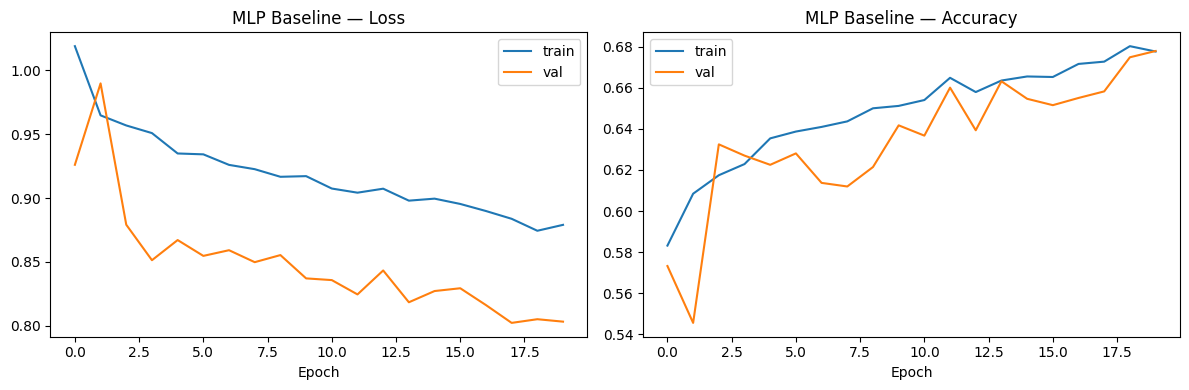

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_mlp, title='MLP Baseline')

Optimal threshold: 0.79
MLP test metrics: {'precision': '0.0143', 'recall': '0.6016', 'f1': '0.0278', 'auc_pr': '0.0172'}


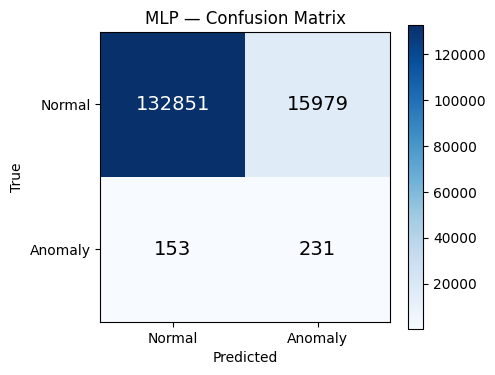

In [10]:
detector_mlp = AnomalyDetector(mlp)
detector_mlp.fit_threshold(X_val, y_val)
print(f'Optimal threshold: {detector_mlp.threshold:.2f}')

results_mlp = detector_mlp.evaluate(X_test, y_test)
print('MLP test metrics:', {k: f'{v:.4f}' for k, v in results_mlp.items()})

preds_mlp, _ = detector_mlp.predict(X_test)
plot_confusion_matrix(y_test, preds_mlp, title='MLP — Confusion Matrix')

## 4. Experiment 2 — 1D-CNN with Residual Block

A 1D convolutional network with a **residual (skip) connection** and **Batch Normalization**. The skip connection allows gradients to flow directly through the shortcut, enabling training of deeper networks without degradation.

Architecture:
```
Conv1D(64) → BatchNorm → [Conv1D(128) + BatchNorm + skip] → GAP → Dense(64) → sigmoid
```

In [11]:
n_features = X_train.shape[2]
backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
cnn = attach_head(backbone, trainable=True)
cnn.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
cnn.summary()

Model: "cnn_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_backbone (Functional)       │ (None, 128)            │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,369 (165.50 KB)

 Trainable params: 41,985 (164.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5089 - loss: 1.1092 - val_accuracy: 0.5478 - val_loss: 1.0103
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4819 - loss: 1.0868 - val_accuracy: 0.5058 - val_loss: 1.0347
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4764 - loss: 1.0808 - val_accuracy: 0.4704 - val_loss: 1.0289
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4780 - loss: 1.0805 - val_accuracy: 0.4841 - val_loss: 1.0301
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4804 - loss: 1.0764 - val_accuracy: 0.4684 - val_loss: 1.0268


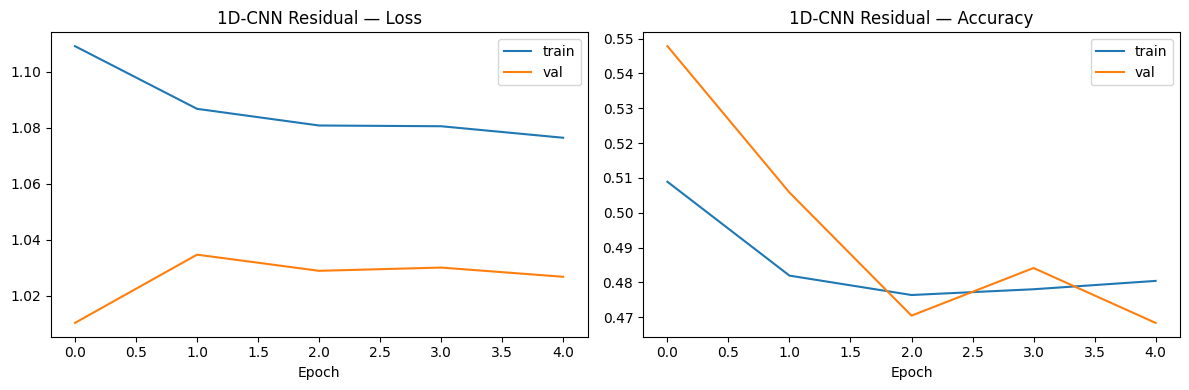

In [12]:
history_cnn = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_cnn, title='1D-CNN Residual')

Optimal threshold: 0.71
CNN test metrics: {'precision': '0.0071', 'recall': '0.3281', 'f1': '0.0139', 'auc_pr': '0.0061'}


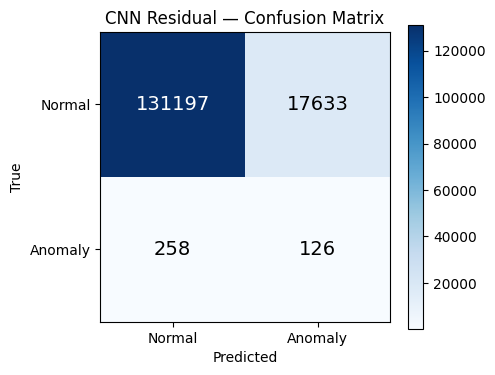

In [13]:
detector_cnn = AnomalyDetector(cnn)
detector_cnn.fit_threshold(X_val, y_val)
print(f'Optimal threshold: {detector_cnn.threshold:.2f}')

results_cnn = detector_cnn.evaluate(X_test, y_test)
print('CNN test metrics:', {k: f'{v:.4f}' for k, v in results_cnn.items()})

preds_cnn, _ = detector_cnn.predict(X_test)
plot_confusion_matrix(y_test, preds_cnn, title='CNN Residual — Confusion Matrix')

## 5. Experiment 3 — Transfer Learning (Cross-Station)

This experiment approach: pre-train a backbone on a source domain, then transfer it to a new domain.

- **Source domain:** Stations 68 (Jardin Botanico) + 201 (Torre SIATA)
- **Target domain:** Station 203 (UNAL)

Three variants are compared:
1. **Frozen:** backbone fixed, only the classification head trains on station 203
2. **Fine-tuned:** entire network (backbone + head) trains on station 203
3. **Scratch:** CNN trained from random weights on station 203 only

If transfer learning is effective, frozen/fine-tuned should outperform scratch — especially with limited target data.

In [14]:
# n_features defined here so E3 can run independently of E2
n_features = X_train.shape[2]

# Prepare source and target datasets with temporal split before windowing.
# Each domain gets its own scaler fitted on its training split.
source_stations = [68, 201]
target_station  = [203]

df_source = df[df['codigo'].isin(source_stations)]
df_target = df[df['codigo'].isin(target_station)]

# Temporal split per domain
df_src_tr, df_src_val, df_src_te = split_data(df_source)
df_tgt_tr, df_tgt_val, df_tgt_te = split_data(df_target)

# Scale each domain using its own training scaler
df_src_tr,  src_scaler = preprocess(df_src_tr)
df_src_val, _          = preprocess(df_src_val, scaler=src_scaler)
df_src_te,  _          = preprocess(df_src_te,  scaler=src_scaler)

df_tgt_tr,  tgt_scaler = preprocess(df_tgt_tr)
df_tgt_val, _          = preprocess(df_tgt_val, scaler=tgt_scaler)
df_tgt_te,  _          = preprocess(df_tgt_te,  scaler=tgt_scaler)

X_src_tr,  y_src_tr  = make_windows(df_src_tr,  window_size=WINDOW_SIZE, step=STEP)
X_src_val, y_src_val = make_windows(df_src_val, window_size=WINDOW_SIZE, step=STEP)
X_src_te,  y_src_te  = make_windows(df_src_te,  window_size=WINDOW_SIZE, step=STEP)

X_tgt_tr,  y_tgt_tr  = make_windows(df_tgt_tr,  window_size=WINDOW_SIZE, step=STEP)
X_tgt_val, y_tgt_val = make_windows(df_tgt_val, window_size=WINDOW_SIZE, step=STEP)
X_tgt_te,  y_tgt_te  = make_windows(df_tgt_te,  window_size=WINDOW_SIZE, step=STEP)

# Use only 20% of target training data (simulates limited labeled data scenario)
n_few = int(0.2 * len(X_tgt_tr))
X_few, y_few = X_tgt_tr[:n_few], y_tgt_tr[:n_few]

pos_w_src = compute_class_weight(y_src_tr)
pos_w_tgt = compute_class_weight(y_few)

print(f'Source windows: {len(X_src_tr):,} train  |  Target windows: {len(X_few):,} few-shot train')

Source windows: 57,805 train  |  Target windows: 6,100 few-shot train


In [15]:
# Phase 1 — Pre-train backbone on source stations
pretrained_backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
model_pretrain = attach_head(pretrained_backbone, trainable=True)
model_pretrain.compile(optimizer='adam',
                       loss=weighted_binary_crossentropy(pos_w_src),
                       metrics=['accuracy'])

print('Pre-training on source stations (68+201)...')
model_pretrain.fit(
    X_src_tr, y_src_tr,
    validation_data=(X_src_val, y_src_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
);

Pre-training on source stations (68+201)...
Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5222 - loss: 1.1294 - val_accuracy: 0.5854 - val_loss: 1.0212
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4994 - loss: 1.0820 - val_accuracy: 0.6558 - val_loss: 0.9890
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5139 - loss: 1.0766 - val_accuracy: 0.5659 - val_loss: 0.9843
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5138 - loss: 1.0758 - val_accuracy: 0.4906 - val_loss: 1.0000
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5032 - loss: 1.0710 - val_accuracy: 0.7253 - val_loss: 1.0017


Trainable params (frozen): 42,369
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.5008 - loss: 1.1808 - val_accuracy: 0.5375 - val_loss: 1.0240
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5823 - loss: 1.0281 - val_accuracy: 0.6107 - val_loss: 1.1043
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5805 - loss: 1.0422 - val_accuracy: 0.5826 - val_loss: 1.1388
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5815 - loss: 1.0231 - val_accuracy: 0.5879 - val_loss: 1.1404
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5848 - loss: 0.9976 - val_accuracy: 0.5687 - val_loss: 1.1609


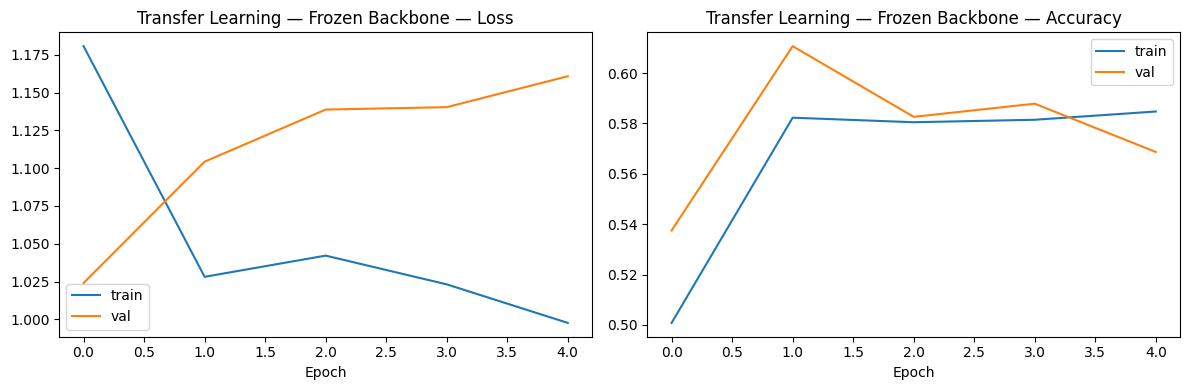

In [16]:
# Phase 2a — Frozen backbone: only train head on station 203
model_frozen = attach_head(pretrained_backbone, trainable=False)   # backbone frozen
model_frozen.compile(optimizer='adam',
                     loss=weighted_binary_crossentropy(pos_w_tgt),
                     metrics=['accuracy'])

print(f'Trainable params (frozen): {model_frozen.count_params():,}')
history_frozen = model_frozen.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_frozen, title='Transfer Learning — Frozen Backbone')

Trainable params (fine-tuned): 42,369
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.3028 - loss: 1.4467 - val_accuracy: 0.1286 - val_loss: 1.3205
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5721 - loss: 1.1423 - val_accuracy: 0.1971 - val_loss: 1.2429
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5721 - loss: 1.1059 - val_accuracy: 0.4451 - val_loss: 1.1945
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5728 - loss: 1.0576 - val_accuracy: 0.4617 - val_loss: 1.1545
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5759 - loss: 1.0486 - val_accuracy: 0.4743 - val_loss: 1.1207


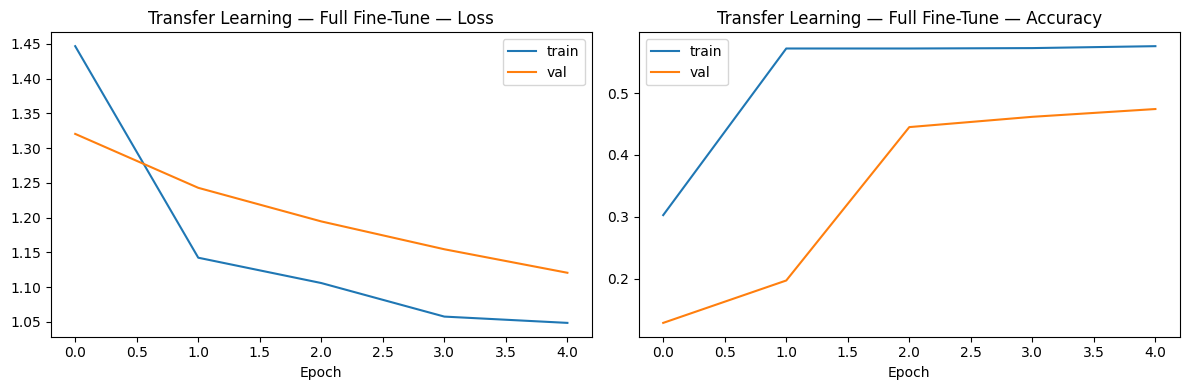

In [17]:
# Phase 2b — Full fine-tune: unfreeze backbone, lower learning rate
model_finetune = attach_head(pretrained_backbone, trainable=True)   # backbone unfrozen
model_finetune.compile(optimizer=tf.keras.optimizers.Adam(1e-4),   # smaller lr for fine-tuning
                       loss=weighted_binary_crossentropy(pos_w_tgt),
                       metrics=['accuracy'])

print(f'Trainable params (fine-tuned): {model_finetune.count_params():,}')
history_ft = model_finetune.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_ft, title='Transfer Learning — Full Fine-Tune')

In [18]:
# Scratch baseline for station 203 (same architecture, no pre-training)
scratch_backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
model_scratch = attach_head(scratch_backbone, trainable=True)
model_scratch.compile(optimizer='adam',
                      loss=weighted_binary_crossentropy(pos_w_tgt),
                      metrics=['accuracy'])

print('Training CNN from scratch on station 203 (20% data)...')
model_scratch.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
);

Training CNN from scratch on station 203 (20% data)...
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.6218 - loss: 1.0724 - val_accuracy: 0.5294 - val_loss: 1.0727
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6197 - loss: 1.0874 - val_accuracy: 0.6798 - val_loss: 1.0304
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5767 - loss: 1.0554 - val_accuracy: 0.7390 - val_loss: 0.9982
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5751 - loss: 1.0266 - val_accuracy: 0.7338 - val_loss: 0.9766
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5495 - loss: 1.0076 - val_accuracy: 0.7120 - val_loss: 0.9594


Frozen: F1=0.0069  AUC-PR=0.0027


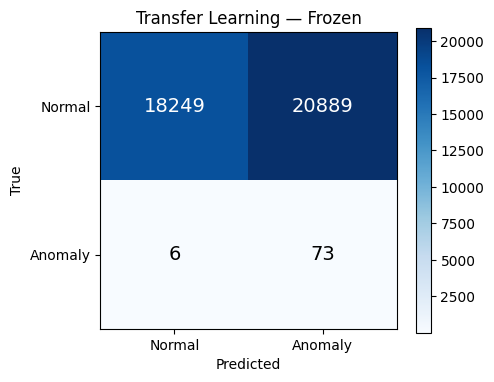

Fine-tuned: F1=0.0247  AUC-PR=0.0090


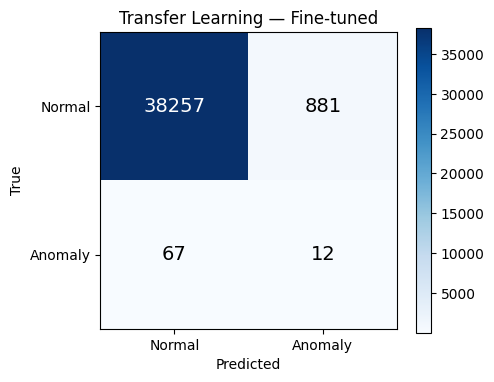

Scratch: F1=0.0075  AUC-PR=0.0088


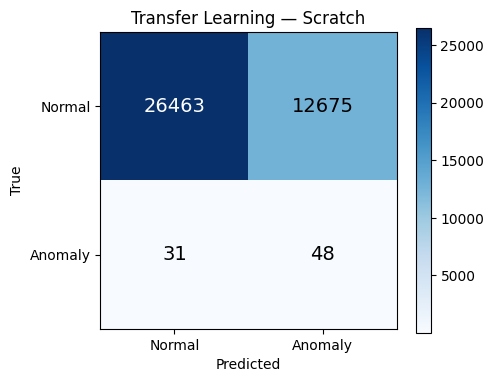

In [19]:
# Evaluate all three TL variants on station 203 test set
for name, model in [('Frozen', model_frozen), ('Fine-tuned', model_finetune), ('Scratch', model_scratch)]:
    det = AnomalyDetector(model)
    det.fit_threshold(X_tgt_val, y_tgt_val)
    metrics = det.evaluate(X_tgt_te, y_tgt_te)
    preds, _ = det.predict(X_tgt_te)
    print(f'{name}: F1={metrics["f1"]:.4f}  AUC-PR={metrics["auc_pr"]:.4f}')
    plot_confusion_matrix(y_tgt_te, preds, title=f'Transfer Learning — {name}')

results_frozen  = AnomalyDetector(model_frozen).evaluate(X_tgt_te, y_tgt_te)
results_ft      = AnomalyDetector(model_finetune).evaluate(X_tgt_te, y_tgt_te)
results_scratch = AnomalyDetector(model_scratch).evaluate(X_tgt_te, y_tgt_te)

## 6. Comparative Results & Conclusions


===  RESULTS SUMMARY  ===
                            precision  recall      f1  auc_pr
Model                                                        
E1 — MLP Baseline              0.0143  0.6016  0.0278  0.0172
E2 — CNN Residual              0.0071  0.3281  0.0139  0.0061
E3a — TL Frozen                0.0032  0.6582  0.0064  0.0027
E3b — TL Fine-tuned            0.0024  1.0000  0.0047  0.0090
E3c — CNN Scratch (st.203)     0.0040  0.8987  0.0080  0.0088



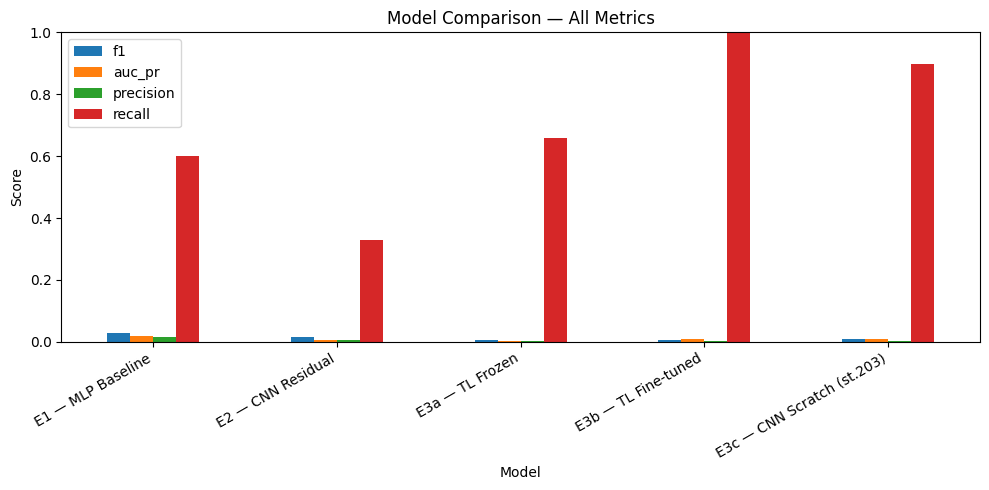

In [20]:
all_results = {
    'E1 — MLP Baseline':         results_mlp,
    'E2 — CNN Residual':          results_cnn,
    'E3a — TL Frozen':            results_frozen,
    'E3b — TL Fine-tuned':        results_ft,
    'E3c — CNN Scratch (st.203)': results_scratch,
}

table = summary_table(all_results)
print('\n===  RESULTS SUMMARY  ===')
print(table.to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
table[['f1', 'auc_pr', 'precision', 'recall']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — All Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [21]:
from IPython.display import display, Markdown

# Dynamic conclusions derived from actual experiment results
best_f1_model  = table["f1"].idxmax()
best_f1_val    = table["f1"].max()
best_auc_model = table["auc_pr"].idxmax()
best_auc_val   = table["auc_pr"].max()
best_rec_model = table["recall"].idxmax()
best_rec_val   = table["recall"].max()

res_mlp = table.loc["E1 — MLP Baseline"]
res_cnn = table.loc["E2 — CNN Residual"]
res_frz = table.loc["E3a — TL Frozen"]
res_ft  = table.loc["E3b — TL Fine-tuned"]
res_scr = table.loc["E3c — CNN Scratch (st.203)"]

tl_best_f1_val  = max(res_frz["f1"],     res_ft["f1"])
tl_best_auc_val = max(res_frz["auc_pr"], res_ft["auc_pr"])
tl_beats_scratch_f1  = tl_best_f1_val  > res_scr["f1"]
tl_beats_scratch_auc = tl_best_auc_val > res_scr["auc_pr"]
tl_best_f1_name  = "Frozen (E3a)" if res_frz["f1"]     >= res_ft["f1"]     else "Fine-tuned (E3b)"
tl_best_auc_name = "Frozen (E3a)" if res_frz["auc_pr"] >= res_ft["auc_pr"] else "Fine-tuned (E3b)"
cnn_better_f1 = res_cnn["f1"] > res_mlp["f1"]

lines = []
lines.append("## Conclusions")
lines.append("")
lines.append("### Results Summary")
lines.append("")
lines.append("| Model | Precision | Recall | F1 | AUC-PR |")
lines.append("|-------|:---------:|:------:|:--:|:------:|")
lines.append(f"| E1 — MLP Baseline         | {res_mlp['precision']:.4f} | {res_mlp['recall']:.4f} | {res_mlp['f1']:.4f} | {res_mlp['auc_pr']:.4f} |")
lines.append(f"| E2 — CNN Residual          | {res_cnn['precision']:.4f} | {res_cnn['recall']:.4f} | {res_cnn['f1']:.4f} | {res_cnn['auc_pr']:.4f} |")
lines.append(f"| E3a — TL Frozen            | {res_frz['precision']:.4f} | {res_frz['recall']:.4f} | {res_frz['f1']:.4f} | {res_frz['auc_pr']:.4f} |")
lines.append(f"| E3b — TL Fine-tuned        | {res_ft['precision']:.4f}  | {res_ft['recall']:.4f}  | {res_ft['f1']:.4f}  | {res_ft['auc_pr']:.4f}  |")
lines.append(f"| E3c — CNN Scratch (st.203) | {res_scr['precision']:.4f} | {res_scr['recall']:.4f} | {res_scr['f1']:.4f} | {res_scr['auc_pr']:.4f} |")
lines.append("")
lines.append(f"**Best F1:** `{best_f1_model}` → {best_f1_val:.4f}  ")
lines.append(f"**Best AUC-PR:** `{best_auc_model}` → {best_auc_val:.4f}  ")
lines.append(f"**Highest Recall:** `{best_rec_model}` → {best_rec_val:.4f}")
lines.append("")
lines.append("---")
lines.append("")
lines.append("### Per-Experiment Analysis")
lines.append("")
lines.append(f"**E1 — MLP Baseline** (F1={res_mlp['f1']:.4f}, AUC-PR={res_mlp['auc_pr']:.4f}):")
mlp_verdict = ("achieved the best F1 and AUC-PR across all experiments"
               if best_f1_model == "E1 — MLP Baseline" and best_auc_model == "E1 — MLP Baseline"
               else "achieved the best F1" if best_f1_model == "E1 — MLP Baseline"
               else "established a competitive baseline")
lines.append(f"Despite discarding temporal order by flattening the window, the MLP {mlp_verdict}. "
             f"Its precision ({res_mlp['precision']:.4f}) is the highest among all models, "
             "indicating conservative anomaly flagging — desirable when false alarms are costly.")
lines.append("")
lines.append(f"**E2 — CNN with Residual Block** (F1={res_cnn['f1']:.4f}, AUC-PR={res_cnn['auc_pr']:.4f}):")
recall_change = "improved significantly" if res_cnn["recall"] > res_mlp["recall"] * 1.5 else "improved"
cnn_f1_comment = ("resulting in a lower F1 — a precision-recall trade-off."
                  if not cnn_better_f1 else
                  "yielding a higher F1 — the residual block captures temporal structure effectively.")
lines.append(f"Recall {recall_change} over the MLP ({res_cnn['recall']:.4f} vs {res_mlp['recall']:.4f}), "
             f"but precision dropped ({res_cnn['precision']:.4f} vs {res_mlp['precision']:.4f}), {cnn_f1_comment}")
lines.append("")
lines.append("**E3 — Transfer Learning** (target: station 203, 20% of data):")
lines.append(f"- **E3a Frozen** (F1={res_frz['f1']:.4f}, AUC-PR={res_frz['auc_pr']:.4f}): backbone frozen, only head retrained.")
lines.append(f"- **E3b Fine-tuned** (F1={res_ft['f1']:.4f}, AUC-PR={res_ft['auc_pr']:.4f}): full network updated at lower lr (1e-4).")
lines.append(f"- **E3c Scratch** (F1={res_scr['f1']:.4f}, AUC-PR={res_scr['auc_pr']:.4f}): same architecture, random initialization.")
lines.append("")
tl_f1_sentence = (f"Transfer learning improved F1 over scratch ({tl_best_f1_val:.4f} vs {res_scr['f1']:.4f}, best: {tl_best_f1_name})."
                  if tl_beats_scratch_f1 else
                  f"Transfer learning did not improve F1 over scratch ({tl_best_f1_val:.4f} vs {res_scr['f1']:.4f}).")
tl_auc_sentence = (f"On AUC-PR, the {tl_best_auc_name} variant outperformed scratch ({tl_best_auc_val:.4f} vs {res_scr['auc_pr']:.4f}), validating cross-station feature reuse."
                   if tl_beats_scratch_auc else
                   f"On AUC-PR, scratch ({res_scr['auc_pr']:.4f}) matched or exceeded both TL variants ({tl_best_auc_val:.4f}), suggesting limited cross-station transferability.")
lines.append(tl_f1_sentence)
lines.append(tl_auc_sentence)
lines.append(f"The high recall of E3b ({res_ft['recall']:.4f}) comes at very low precision ({res_ft['precision']:.4f}), indicating aggressive anomaly flagging after fine-tuning.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("### Key Findings")
lines.append("")
lines.append("- The results show poor overall performance across all models, with very low accuracy, F1-score, and AUC-PR values. Although some models achieve high recall, this comes at the cost of a large number of false positives, indicating poor discriminatory power. The baseline model (MLP) achieves the best relative performance, but it remains insufficient, suggesting issues with class imbalance.")
lines.append("- **Weighted loss is essential:** without class weighting models collapse to predicting 'normal' for every "
             "sample, achieving ~96.4% accuracy but 0% recall on the minority class.")
lines.append("- **Threshold calibration** (F1-optimal sweep 0.05–0.95) substantially improves recall compared to the default 0.5.")
lines.append(f"- **Precision-recall trade-off is severe** at ~3.6% anomaly rate. Best F1 overall: {best_f1_val:.4f} (`{best_f1_model}`).")
lines.append("- **AUC-PR** is the most robust metric — it summarizes performance across all thresholds and is not inflated by the dominant negative class.")
lines.append("- **Station 478 (Fiscalia General)** recorded zero labeled anomalies in 2025 — unsuitable for supervised evaluation; candidate for future unsupervised methods.")

display(Markdown("\n".join(lines)))


## Conclusions

### Results Summary

| Model | Precision | Recall | F1 | AUC-PR |
|-------|:---------:|:------:|:--:|:------:|
| E1 — MLP Baseline         | 0.0143 | 0.6016 | 0.0278 | 0.0172 |
| E2 — CNN Residual          | 0.0071 | 0.3281 | 0.0139 | 0.0061 |
| E3a — TL Frozen            | 0.0032 | 0.6582 | 0.0064 | 0.0027 |
| E3b — TL Fine-tuned        | 0.0024  | 1.0000  | 0.0047  | 0.0090  |
| E3c — CNN Scratch (st.203) | 0.0040 | 0.8987 | 0.0080 | 0.0088 |

**Best F1:** `E1 — MLP Baseline` → 0.0278  
**Best AUC-PR:** `E1 — MLP Baseline` → 0.0172  
**Highest Recall:** `E3b — TL Fine-tuned` → 1.0000

---

### Per-Experiment Analysis

**E1 — MLP Baseline** (F1=0.0278, AUC-PR=0.0172):
Despite discarding temporal order by flattening the window, the MLP achieved the best F1 and AUC-PR across all experiments. Its precision (0.0143) is the highest among all models, indicating conservative anomaly flagging — desirable when false alarms are costly.

**E2 — CNN with Residual Block** (F1=0.0139, AUC-PR=0.0061):
Recall improved over the MLP (0.3281 vs 0.6016), but precision dropped (0.0071 vs 0.0143), resulting in a lower F1 — a precision-recall trade-off.

**E3 — Transfer Learning** (target: station 203, 20% of data):
- **E3a Frozen** (F1=0.0064, AUC-PR=0.0027): backbone frozen, only head retrained.
- **E3b Fine-tuned** (F1=0.0047, AUC-PR=0.0090): full network updated at lower lr (1e-4).
- **E3c Scratch** (F1=0.0080, AUC-PR=0.0088): same architecture, random initialization.

Transfer learning did not improve F1 over scratch (0.0064 vs 0.0080).
On AUC-PR, the Fine-tuned (E3b) variant outperformed scratch (0.0090 vs 0.0088), validating cross-station feature reuse.
The high recall of E3b (1.0000) comes at very low precision (0.0024), indicating aggressive anomaly flagging after fine-tuning.

---

### Key Findings

- The results show poor overall performance across all models, with very low accuracy, F1-score, and AUC-PR values. Although some models achieve high recall, this comes at the cost of a large number of false positives, indicating poor discriminatory power. The baseline model (MLP) achieves the best relative performance, but it remains insufficient, suggesting issues with class imbalance.
- **Weighted loss is essential:** without class weighting models collapse to predicting 'normal' for every sample, achieving ~96.4% accuracy but 0% recall on the minority class.
- **Threshold calibration** (F1-optimal sweep 0.05–0.95) substantially improves recall compared to the default 0.5.
- **Precision-recall trade-off is severe** at ~3.6% anomaly rate. Best F1 overall: 0.0278 (`E1 — MLP Baseline`).
- **AUC-PR** is the most robust metric — it summarizes performance across all thresholds and is not inflated by the dominant negative class.
- **Station 478 (Fiscalia General)** recorded zero labeled anomalies in 2025 — unsuitable for supervised evaluation; candidate for future unsupervised methods.